# Using Hugging Face Models and Choosing an Adaptation Strategy

**Hugging Face Models and Fine-Tuning · Lecture 1 · self-paced tutorial**  
**Estimated study time:** 60–90 minutes, excluding model downloads and optional large-model extensions  
**Typical code runtime:** 25–35 minutes

## Learning outcomes

- Identify the artifacts needed to reproduce a model.
- Run the tokenizer-to-generation inference path.
- Compare Qwen3.5 thinking and direct modes using latency and output-token evidence.
- Build image/video messages and adapt to model-specific output contracts.
- Compare Qwen3.5 thinking and direct modes using latency and output-token evidence.
- Build image/video messages and adapt to model-specific output contracts.
- Compare Qwen3.5 thinking and direct modes using latency and output-token evidence.
- Build image/video messages and adapt to model-specific output contracts.
- Compare Qwen3.5 thinking and direct modes using latency and output-token evidence.
- Build image/video messages and adapt to model-specific output contracts.
- Compare Qwen3.5 thinking and direct modes using latency and output-token evidence.
- Build image/video messages and adapt to model-specific output contracts.
- Compare Qwen3.5 thinking and direct modes using latency and output-token evidence.
- Build image/video messages and adapt to model-specific output contracts.
- Choose among prompting, few-shot examples, RAG, fine-tuning, and continued pretraining.

| Learning stage | What you will do |
|---|---|
| Orient | Read the driving question and prerequisite recap. |
| Build intuition | Work through the visual model and hand calculation. |
| Implement | Run the code in order and investigate the first failed check. |
| Consolidate | Complete the practice checkpoint and summarize the evidence. |

## Driving question

> **When a model performs poorly, should we change the prompt, supply evidence, or update weights?**

Keep this question in mind as you work. Each calculation, figure, and
code cell gives you one more piece of the answer.

### Before you begin

You need the causal-language-model loop: messages become token IDs, the model emits logits, and decoding selects continuation IDs. Course 1 artifacts are not required.

Begin with one support task that produces an unstructured, outdated answer. That symptom is ambiguous. Clearer instructions address task ambiguity; few-shot examples demonstrate a format; RAG supplies private or changing facts; supervised fine-tuning changes repeated behavior; continued pretraining adapts broad domain language. We will make the decision before loading a large model, then trace the complete artifact and inference contracts needed to reproduce the chosen baseline.

Do not begin by assuming that fine-tuning is the answer. A clearer prompt may fix an instruction problem, examples may fix an output-format problem, and retrieval may supply missing current knowledge. Fine-tuning is most useful when the desired behavior must be learned repeatedly and evaluated on held-out tasks.

## How this lesson builds, step by step

We start with a weak answer and diagnose whether it lacks instructions, examples, evidence, behavior, or domain exposure. That diagnosis determines whether prompting, few-shot examples, RAG, fine-tuning, or continued pretraining is the smallest sensible change. We then inspect a pinned Hub repository, choose the correct Auto class, render a real chat template, and trace one real SmolLM2 request from messages to token IDs, logits, and decoded continuation. The final failure test separates formatting mistakes from weight behavior.

## Reproducible setup

This course is self-contained. The cell below finds this downloaded folder and adds it to Python's import path; it never searches for the repository-level `shared` package. Run the setup notebook first so the pinned packages and data hashes are checked.

In [ ]:
from pathlib import Path
import json, random, sys

COURSE_ROOT = next(
    candidate for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (candidate / "course_helpers.py").is_file()
)
if str(COURSE_ROOT) not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT))

SEED = 2026
random.seed(SEED)
print("Course folder:", COURSE_ROOT)

### A Hub repository is an artifact bundle

Configuration, tokenizer, weights, generation settings, and the model card play different roles.

**Check your understanding:** Which artifact tells you the architecture, and which one determines the exact token sequence seen by the model?

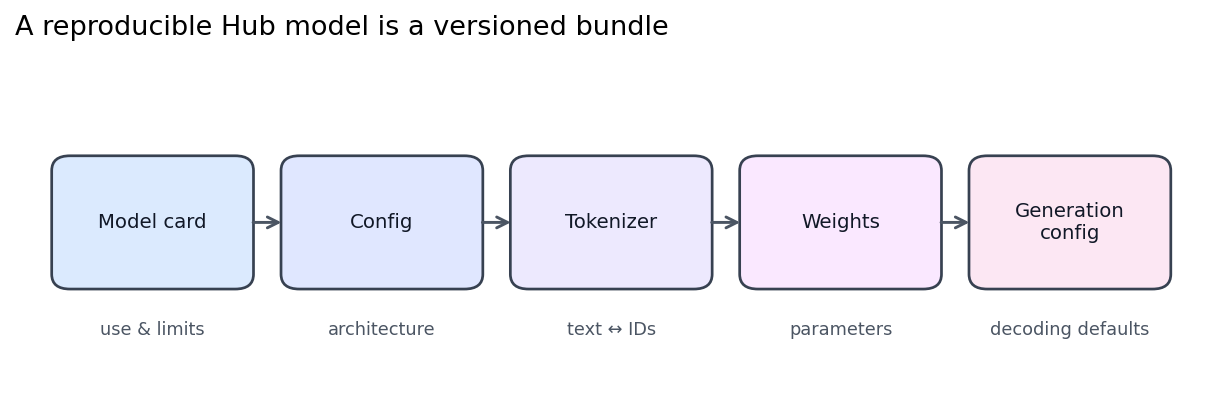

## Learn and test: Inspect the artifact bundle

A Hub repository is a versioned artifact bundle. Before changing weights, diagnose the gap: prompting changes instructions, few-shot examples demonstrate a format, RAG supplies current evidence, fine-tuning changes behavior, and continued pretraining adapts domain language. Choose the smallest intervention that addresses the observed failure.

## A model is a versioned artifact bundle

`from_pretrained` looks simple because the library coordinates several files. The configuration declares architecture and dimensions. Tokenizer artifacts define normalization, vocabulary, merge rules, special tokens, and sometimes a chat template. Weight shards contain tensors. Generation configuration supplies decoding defaults. The model card should document training context, intended use, license, evaluation, and limitations.

### Work the smallest useful example

A Hub model is not one file. Configuration chooses architecture and dimensions; tokenizer files define text-to-ID behavior and chat formatting; weight shards store parameters; generation configuration supplies defaults; the model card documents license and limitations. A base model continues text, while an instruct model has learned role-formatted conversations. Applying the wrong chat template changes the actual token sequence and can dominate any apparent model comparison.

Keep this result visible. The code should reproduce the same relationship; if
it does not, locate the first value that differs before changing the model.

### Choose the smallest intervention that fits the problem

Prompting changes instructions, retrieval supplies evidence, and fine-tuning changes model behavior.

**Check your understanding:** For a failure caused by missing current facts, which branch addresses the cause without updating weights?

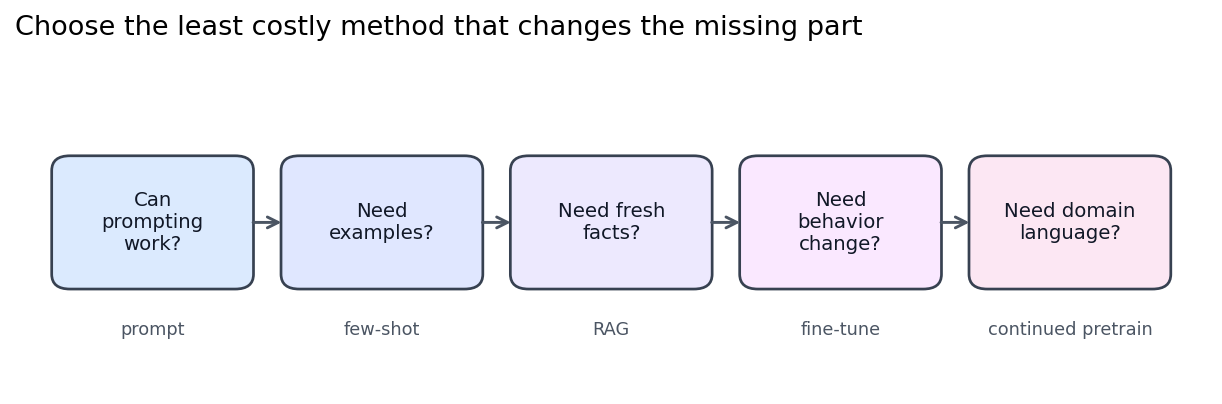

### Try it: Inspect the artifact bundle

**What this cell shows**

Identify every file needed before attributing behavior to weights.

**What goes in and comes out**

- Artifact names map to roles
- config fields are scalars describing layers, width, and model type.

**Follow the calculation**

1. Inspect model card, config, tokenizer, weights, and generation config separately. Pin the same revision for related artifacts.

**Before you run the cell**

Which missing artifact prevents text from being interpreted as the training format? Write down the expected value, shape, or ordering before running the cell.

In [ ]:
artifact_roles = {
    "config.json": "architecture and hyperparameters",
    "tokenizer.json": "normalization, pre-tokenization, vocabulary, merges",
    "model.safetensors": "parameter tensors",
    "generation_config.json": "decoding defaults",
    "README.md": "model card, license, evaluation, limitations",
}
for name, role in artifact_roles.items(): print(f"{name:24s} {role}")

**What you should see**

The tokenizer and chat template are as necessary as weights for faithful use.

**If your result looks different**

A repository name without a revision is not a reproducibility record.

Before moving on, compare the output with your prediction. If they differ, use the data description and tensor shapes above to find the first unexpected step.

## Learn and test: inspect a model configuration before loading its weights

Hugging Face model repositories can change over time. The `revision` argument selects one exact repository version—here, a commit hash—so everyone receives the same configuration, tokenizer, and weights. It is similar to citing a specific edition of a textbook instead of saying only “use the textbook.”

`AutoConfig.from_pretrained` downloads only the small configuration file, not the model weights. On the first run it uses the internet; afterward Hugging Face reuses the cached file. We intentionally do **not** use `local_files_only=True`, because this course permits first-run downloads.

The configuration tells an Auto class which architecture to construct. `AutoModel` returns hidden representations without a task head, while `AutoModelForCausalLM` adds the next-token prediction head needed for generation.

### Try it: inspect the pinned classroom configuration

**What goes in:** the classroom model ID and its pinned revision. **What comes out:** a small Python configuration object; the 135M weight tensors are not loaded yet.

**Before running:** predict whether `num_hidden_layers` and `hidden_size` describe data shapes or model architecture. If this is the first run, internet access is required.

**Inputs and outputs:** The named Python objects enter this step; the printed values, token counts, tensor shapes, or saved files are the observations to check.

In [ ]:
from transformers import AutoConfig
from course_helpers import CLASSROOM_MODEL, CLASSROOM_REVISION

config = AutoConfig.from_pretrained(
    CLASSROOM_MODEL,
    revision=CLASSROOM_REVISION,
)
print("model type:", config.model_type)
print("hidden layers:", config.num_hidden_layers)
print("hidden width:", config.hidden_size)

**What the result means:** these values describe the architecture that Transformers will construct when Lecture 01 loads the weights. No `B × T` input tensor exists yet, and downloading the configuration does not allocate 135M model parameters.

**If something fails:** a connection error means the file is not cached and the current node cannot reach Hugging Face. Fix the network connection and rerun the cell. Do not catch every exception and label it an “offline skip,” because that can hide a misspelled model ID or incompatible configuration.

## Learn and test: Choose the correct model family

### Base versus instruction models

A base causal model continues text according to pretraining. An instruction model has additional post-training that teaches conversational roles and response patterns. They may share architecture but require different prompting. A chat template converts structured role/content messages into the exact token sequence used during post-training.

### Decide before fine-tuning

If clearer instructions solve the task, use prompting. If the model needs to imitate a few examples, try few-shot prompting. If answers require private or changing facts with citations, use RAG. Fine-tune when repeated evidence shows a stable behavior, format, or task skill must change. Continued pretraining is a separate choice for adapting broad domain language and usually needs much more unlabeled text. Test the cheapest plausible intervention on the same held-out prompts before committing GPU time.

### Auto-class decision

Use `AutoModel` for hidden representations, `AutoModelForCausalLM` for next-token generation, `AutoModelForSequenceClassification` for labeled classification, and `AutoModelForSeq2SeqLM` for encoder-decoder generation.

### Trace text through a Hugging Face model

Messages are formatted, tokenized, batched, scored, sliced, and decoded across several interfaces.

**Check your understanding:** Where could the original prompt accidentally appear in the decoded answer?

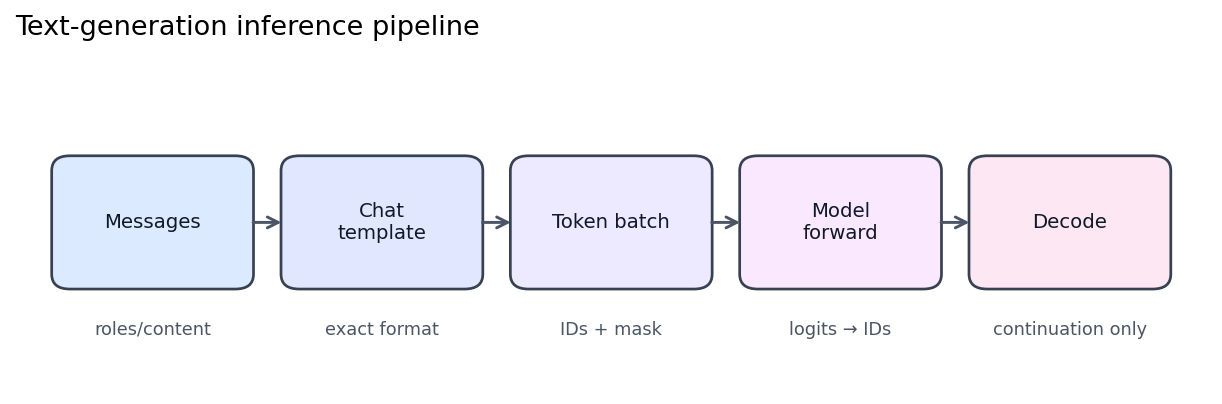

### Base and instruction models learned different response conventions

A base model continues text, while an instruction model has been trained to respond to role-structured messages.

**Check your understanding:** What must remain fixed to compare their behavior fairly?

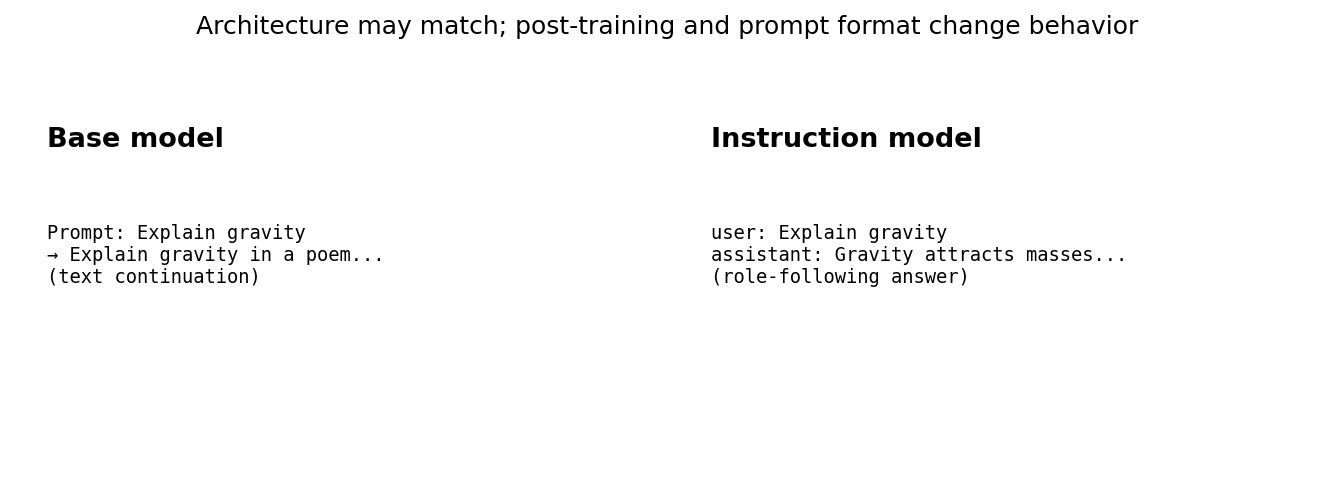

### Try it: Choose the correct model family

**What this cell shows**

Connect encoder, encoder-decoder, and decoder architectures to task heads.

**What goes in and comes out**

- Each table row contains family, architecture, and intended output contract.

**Follow the calculation**

1. `AutoModel` returns representations
2. causal, sequence-classification, and seq2seq heads produce different outputs and losses.

**Before you run the cell**

Which class is required for autoregressive next-token generation? Write down the expected value, shape, or ordering before running the cell.

In [ ]:
model_families = [
    ("BERT", "encoder", "masked representation/classification"),
    ("T5", "encoder-decoder", "conditional sequence generation"),
    ("Qwen2.5", "decoder", "autoregressive generation"),
]
print(*model_families, sep="\n")

**What you should see**

A decoder with a causal-LM head returns vocabulary logits and supports generation.

**If your result looks different**

A successfully loaded wrong class is still a semantic failure.

Before moving on, compare the output with your prediction. If they differ, use the data description and tensor shapes above to find the first unexpected step.

## Learn and test: compare a real base model with its instruction-tuned counterpart

A model ID is not merely a label. It selects a weight artifact, while the revision fixes a particular repository state. We use the small, Apache-2.0 SmolLM2 pair so you can inspect the actual Transformers objects. The optional Qwen2.5-1.5B pair uses the same sequence of operations on a larger model.

Before importing a convenience function, read its complete implementation. It loads the tokenizer and causal-LM class at the same pinned revision, supplies a padding token when needed, chooses BF16 only on CUDA, and switches to evaluation mode. This is a good candidate for a module because Lectures 03 and 04 need exactly the same behavior.

### Try it: write the loading contract explicitly

**Before running:** identify the two network operations and predict why `model.eval()` matters even though no weights are updated.

**Inputs and outputs:** The named Python objects enter this step; the printed values, token counts, tensor shapes, or saved files are the observations to check.

In [ ]:
def load_text_model(model_id, revision, dtype=None):
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(model_id, revision=revision)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    chosen = dtype or (torch.bfloat16 if torch.cuda.is_available() else torch.float32)
    model = AutoModelForCausalLM.from_pretrained(
        model_id, revision=revision, dtype=chosen,
        device_map="auto" if torch.cuda.is_available() else None,
    )
    model.eval()
    return tokenizer, model

`from_pretrained` downloads on the first run and then uses the local cache. `eval()` disables training-time behavior such as dropout; it does not prevent gradients by itself. The maintained copy is in `course_helpers.py`, so later cells import it instead of duplicating it.

### Try it: load the real instruction model

**What goes in:** model ID plus immutable commit. **What comes out:** a tokenizer and a causal LM whose output last dimension equals the tokenizer vocabulary size.

**Internet and cache:** the first run downloads the 135M model weights from Hugging Face. This is a few hundred MB, so wait for the download to finish and keep the notebook connected. Later runs reuse the cached weights.

**Before running:** expect roughly 135 million parameters, not the 1.5 billion parameters used in the CUDA extension.

**Inputs and outputs:** The named Python objects enter this step; the printed values, token counts, tensor shapes, or saved files are the observations to check.

In [ ]:
import torch
from course_helpers import (
    CLASSROOM_MODEL, CLASSROOM_REVISION,
    load_text_model, count_trainable_parameters,
)

tokenizer, instruct_model = load_text_model(CLASSROOM_MODEL, CLASSROOM_REVISION)
counts = count_trainable_parameters(instruct_model)
print("model:", CLASSROOM_MODEL)
print("parameters:", f"{counts['total']:,}")
print("vocabulary:", len(tokenizer))
print("chat template available:", bool(tokenizer.chat_template))

The parameter count and vocabulary size describe different objects: weights are learned numeric values, whereas vocabulary entries define possible token IDs. A present chat template tells us the tokenizer can turn role-labeled messages into the exact control-token sequence expected by this instruction model.

### Try it: trace messages through template, IDs, logits, and decoded continuation

We keep decoding greedy (`do_sample=False`) so the result is reproducible. The generated tensor contains both prompt and continuation, so decoding the entire tensor would repeat the prompt.

**Before running:** predict which dimension of `logits` will equal the vocabulary size and where the new tokens begin.

**Inputs and outputs:** The named Python objects enter this step; the printed values, token counts, tensor shapes, or saved files are the observations to check.

In [ ]:
messages = [{"role": "user", "content": "Explain overfitting in two short sentences."}]
batch = tokenizer.apply_chat_template(
    messages, tokenize=True, add_generation_prompt=True,
    return_tensors="pt", return_dict=True,
)
input_device = instruct_model.get_input_embeddings().weight.device
batch = {name: tensor.to(input_device) for name, tensor in batch.items()}
with torch.inference_mode():
    logits = instruct_model(**batch).logits
    generated = instruct_model.generate(**batch, do_sample=False, max_new_tokens=60)

continuation = generated[0, batch["input_ids"].shape[1]:]
print("input shape:", tuple(batch["input_ids"].shape))
print("logit shape:", tuple(logits.shape))
print("answer:", tokenizer.decode(continuation, skip_special_tokens=True))

For a batch of one prompt, input IDs have shape `1 × T` and logits have shape `1 × T × V`. Generation begins after the original `T` positions. If the answer includes role markers or repeats the question, inspect `apply_chat_template(..., tokenize=False)` before blaming the weights; formatting is part of the model contract.

### Optional: make the base-versus-instruct comparison empirical

The base checkpoint has no instruction-tuning contract, so give both models the same plain-text prefix rather than applying the instruction model's chat template to the base model. Compare behavior, not just fluency.

A tokenizer creates CPU tensors by default. Because `load_text_model()` may place the model on a GPU, move the encoded batch to the token-embedding device before calling `generate()`. Otherwise PyTorch cannot use CPU token IDs as indices into a CUDA embedding table.

In [ ]:
RUN_BASE_COMPARISON = True
if RUN_BASE_COMPARISON:
    from course_helpers import BASE_MODEL, BASE_REVISION

    base_tokenizer, base_model = load_text_model(BASE_MODEL, BASE_REVISION)
    prompt = "Question: Explain overfitting in two short sentences.\nAnswer:"
    input_device = base_model.get_input_embeddings().weight.device
    ids = base_tokenizer(prompt, return_tensors="pt").to(input_device)
    with torch.inference_mode():
        out = base_model.generate(
            **ids, do_sample=False, max_new_tokens=60
        )
    start = ids["input_ids"].shape[1]
    print(base_tokenizer.decode(out[0, start:], skip_special_tokens=True))

Treat one output as an illustration, not a benchmark. The important observation is that instruction tuning changes response conventions; it does not turn every answer into a verified fact. A fairer evaluation freezes many prompts, token budgets, and scoring rules—the subject of Lecture 04.

## Extended GPU lab: thinking, vision, and video models

The SmolLM2 example established the basic Hugging Face contract. Now we keep that contract visible while changing three things that often confuse real applications: whether the model exposes reasoning text, whether the user message contains media, and what Python object the library returns.

These are **opt-in Palmetto 2 labs** because the downloads and GPU requirements differ substantially:

| Model | Purpose here | Approximate repository size / requirement | Recommended use |
|---|---|---|---|
| `Qwen/Qwen3.5-9B` | Same checkpoint in thinking and direct modes; also natively multimodal | About 19 GB of weights | Run on a CUDA GPU; 40–48 GB is more comfortable than 24 GB |
| `Qwen/Qwen3-VL-8B-Instruct` | Explicit image/video processor workflow | About 17.5 GB of BF16 weights | Run one vision model at a time |
| `Qwen/Qwen3-Omni-30B-A3B-*` | Image, audio, and video with text or audio output | Official 15-second-video guidance is roughly 69–79 GB in BF16 | Run only on a suitable large-memory or multi-GPU allocation |

The experiment switches are enabled so that you can run a selected cell without editing its code, but do not use **Run All** for the large-model section. Execute only the experiment that matches your GPU allocation and record the exact model revision. The notebook releases the previous large model before loading the next one; if `device_map="auto"` still offloads layers to CPU, record that fact because the timing is no longer a pure GPU comparison.

### One conversation can have several valid execution contracts

A text prompt, an image question, and a video question all become model inputs, but they do not pass through identical processors or return identical objects.

**Check your understanding:** at which boundary would code that assumes `response.choices[0].message.content` fail when using local Transformers generation?

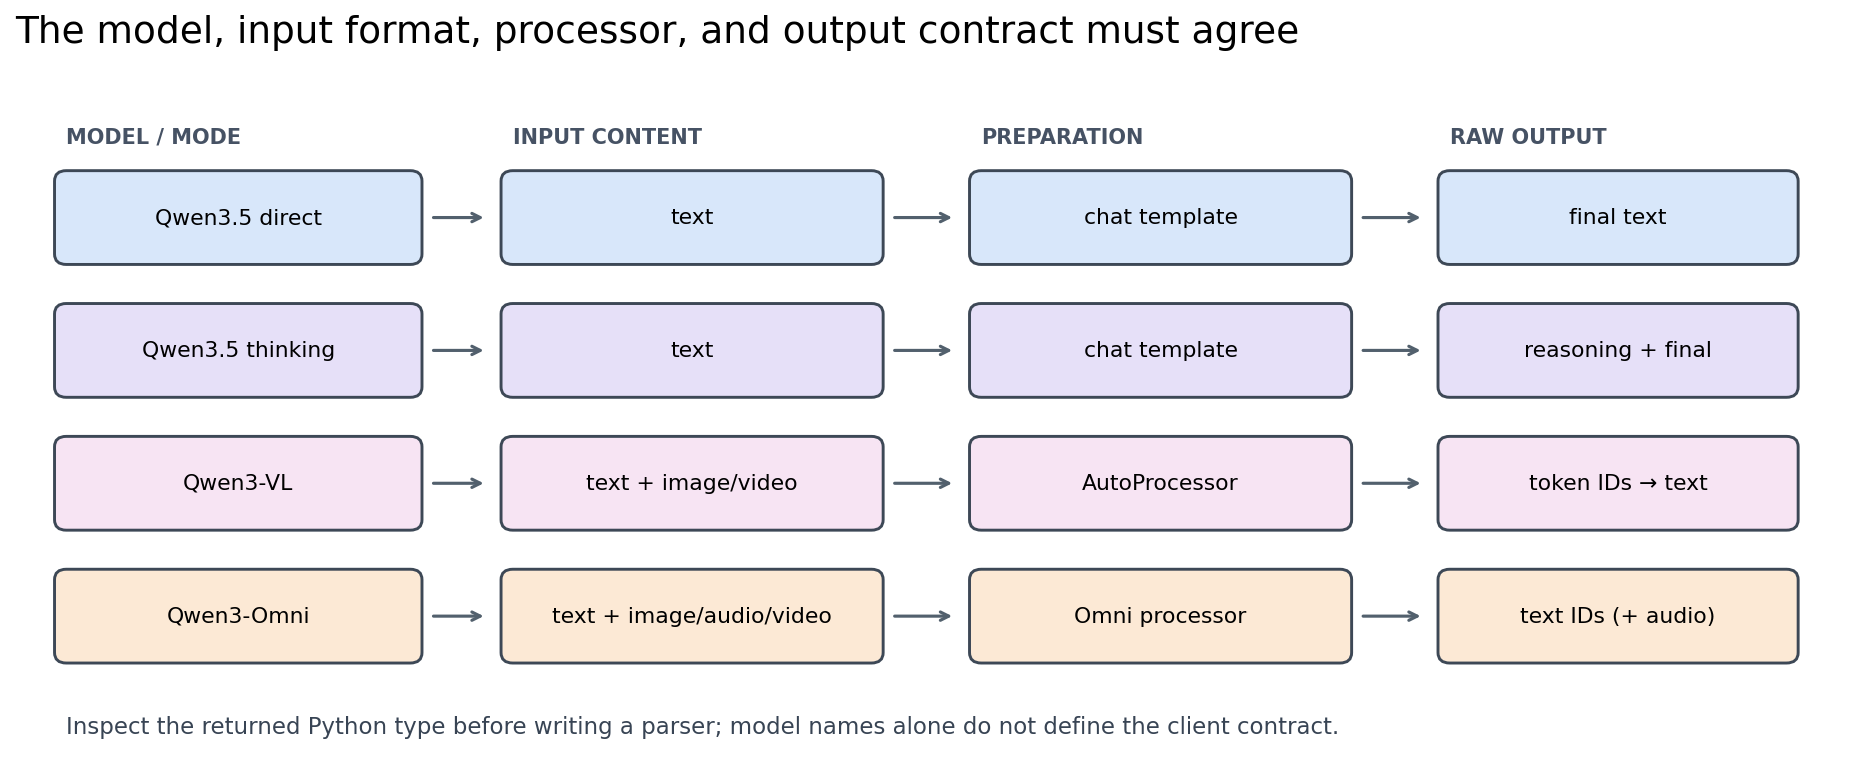

### Thinking and direct response are two modes of the same Qwen3.5 checkpoint

Qwen3.5 thinks by default and may place reasoning before the final answer using `<think> ... </think>`. Its official model card states that `/think` and `/nothink` are not the supported switch for this family. For a local chat template, pass `enable_thinking=False` to request a direct response. An OpenAI-compatible vLLM or SGLang server normally receives the equivalent setting inside `chat_template_kwargs`.

Timing needs a fair contract. Use the same model object, prompt, GPU, and token cap; synchronize CUDA immediately before and after generation; record generated-token count as well as wall time. A thinking answer may be slower mainly because it generates more tokens. Compare both latency and tokens per second rather than attributing every difference to “reasoning overhead.”

The official guidance allows very large output budgets. We use `max_new_tokens=512` for a manageable lab. If the output has `<think>` but no closing `</think>`, the cap probably truncated the reasoning before the final answer. Increase the cap and report the change instead of treating an empty final answer as a parser bug.

### Try it: load Qwen3.5-9B once

This experiment is enabled by default. Before running it, request an appropriate GPU and confirm that about 20 GB of model files can be downloaded or read from cache. The model is loaded once so both modes use identical weights.

Qwen3.5 is a natively multimodal architecture, even in this text-only comparison. We therefore load the full checkpoint with `Qwen3_5ForConditionalGeneration` and prepare its inputs with `AutoProcessor`. Using the named architecture class also gives a clearer compatibility error than depending on the newer `AutoModelForMultimodalLM` alias.

**Before running:** predict whether the processor or the model stores the chat template, and note the GPU model and free memory.

In [ ]:
RUN_QWEN35_LAB = True
observed_outputs = {}

if RUN_QWEN35_LAB:
    import torch
    import transformers
    try:
        from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration
    except ImportError as exc:
        raise ImportError(
            "This lab needs the course Transformers version with Qwen3.5 support. "
            f"Current version: {transformers.__version__}. Install the pinned stack "
            f"from {COURSE_ROOT / 'requirements.txt'}, restart the kernel, and rerun "
            "from the top."
        ) from exc
    from course_helpers import QWEN35_MODEL, QWEN35_REVISION

    assert torch.cuda.is_available(), "Request a Palmetto 2 GPU before this lab."
    qwen35_processor = AutoProcessor.from_pretrained(
        QWEN35_MODEL, revision=QWEN35_REVISION
    )
    qwen35_model = Qwen3_5ForConditionalGeneration.from_pretrained(
        QWEN35_MODEL, revision=QWEN35_REVISION,
        dtype=torch.bfloat16, device_map={"": 0},
    ).eval()
    print("loaded:", QWEN35_MODEL)
    print("input-embedding device:", qwen35_model.get_input_embeddings().weight.device)

The first run downloads the pinned processor and weights; later runs use the cache. This controlled timing experiment deliberately maps the complete model to logical GPU 0. On Palmetto, the scheduler normally exposes the allocated GPU as `cuda:0`. If loading raises an out-of-memory error, request a larger-memory GPU rather than silently offloading layers to CPU; CPU offload would make the latency comparison invalid.

In more general sharded or automatically offloaded models, `model.device` can describe the first parameter rather than the device holding the token-embedding table. Token IDs are integer indices into that table, so both must be on the same device. The timing helper therefore reads the input-embedding device explicitly and verifies the placement before generation.

### Try it: measure thinking and direct modes

The helper below keeps the prompt and generation settings fixed, trims the prompt IDs, synchronizes CUDA for timing, and separates reasoning from the final answer. It returns the raw decoded text as evidence rather than hiding it.

**Before running:** predict which mode will generate more tokens. If both stop at exactly 512 tokens, what additional check is required before comparing final answers?

In [ ]:
def split_qwen35_text(raw_text):
    text = raw_text.replace("<|im_end|>", "").strip()
    if "</think>" not in text:
        if "<think>" in text:
            return {"reasoning": text.split("<think>", 1)[1],
                    "final": "", "complete": False}
        return {"reasoning": None, "final": text, "complete": True}
    reasoning, final = text.split("</think>", 1)
    reasoning = reasoning.replace("<think>", "", 1).strip()
    return {"reasoning": reasoning, "final": final.strip(), "complete": True}

def timed_qwen35(messages, enable_thinking, max_new_tokens=512):
    import time, torch
    input_device = qwen35_model.get_input_embeddings().weight.device
    inputs = qwen35_processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
        enable_thinking=enable_thinking,
    ).to(input_device)
    assert inputs["input_ids"].device == input_device
    torch.cuda.synchronize()
    started = time.perf_counter()
    with torch.inference_mode():
        output = qwen35_model.generate(
            **inputs, do_sample=False, max_new_tokens=max_new_tokens
        )
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - started
    new_ids = output[0, inputs["input_ids"].shape[1]:]
    raw = qwen35_processor.decode(new_ids, skip_special_tokens=False)
    parsed = split_qwen35_text(raw)
    return {**parsed, "raw": raw, "seconds": elapsed,
            "output_tokens": len(new_ids),
            "tokens_per_second": len(new_ids) / elapsed}

This parser handles the local Qwen3.5 text convention; it is not a universal model parser. A server may return reasoning in a separate field, while another library may remove special tokens during decoding. Preserve the raw object and inspect its type before adapting the parser.

In [ ]:
if RUN_QWEN35_LAB:
    test_messages = [{
        "role": "user",
        "content": "A clinic has 17 appointments and 5 rooms. Explain a fair scheduling plan, then give a two-sentence final recommendation."
    }]
    qwen35_results = {}
    for mode_name, enabled in (("direct", False), ("thinking", True)):
        result = timed_qwen35(test_messages, enable_thinking=enabled)
        qwen35_results[mode_name] = result
        print(mode_name, {key: result[key] for key in
              ("seconds", "output_tokens", "tokens_per_second", "complete")})
        print("final:", result["final"][:500])
    observed_outputs["qwen35_raw_text"] = qwen35_results["thinking"]["raw"]

Compare the two records, not just the prose. A useful report includes mode, token cap, completion status, output tokens, seconds, tokens/second, GPU, dtype, device map, and final answer. Run one untimed warm-up before collecting repeated measurements if you want a more stable latency comparison.

### Try it: ask Qwen3-VL-8B-Instruct about a real image

A vision-language model uses `AutoProcessor` because the message contains both text and an image. The processor creates text tokens plus image tensors; the model still returns generated token IDs that must be trimmed and decoded.

This example uses a course-original architecture diagram already stored in `assets/figures`. The cell is enabled by default and releases Qwen3.5 before loading the vision model; confirm that the assigned GPU has enough memory before running it.

In [ ]:
RUN_QWEN3_VL_LAB = True
observed_outputs = globals().get("observed_outputs", {})
if RUN_QWEN3_VL_LAB:
    import gc, time, torch
    from transformers import AutoProcessor, Qwen3VLForConditionalGeneration
    from course_helpers import QWEN3_VL_MODEL, QWEN3_VL_REVISION

    assert torch.cuda.is_available(), "Request a Palmetto 2 GPU before this lab."
    if "qwen35_model" in globals():
        del qwen35_model
        gc.collect()
        torch.cuda.empty_cache()
        print("Released the Qwen3.5 model before loading Qwen3-VL.")
    image_path = COURSE_ROOT / "assets/figures/lecture-01-01-hf_artifacts.png"
    vl_processor = AutoProcessor.from_pretrained(
        QWEN3_VL_MODEL, revision=QWEN3_VL_REVISION
    )
    vl_model = Qwen3VLForConditionalGeneration.from_pretrained(
        QWEN3_VL_MODEL, revision=QWEN3_VL_REVISION,
        dtype=torch.bfloat16, device_map="auto",
    ).eval()
    vl_messages = [{"role": "user", "content": [
        {"type": "image", "image": str(image_path)},
        {"type": "text", "text": "Describe the flow and identify one limitation of this diagram."},
    ]}]
    vl_inputs = vl_processor.apply_chat_template(
        vl_messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    ).to(vl_model.device)
    for name, value in vl_inputs.items():
        print(name, tuple(value.shape), value.dtype)
    torch.cuda.synchronize(); started = time.perf_counter()
    with torch.inference_mode():
        vl_ids = vl_model.generate(**vl_inputs, max_new_tokens=160)
    torch.cuda.synchronize(); vl_seconds = time.perf_counter() - started
    trimmed = vl_ids[:, vl_inputs["input_ids"].shape[1]:]
    vl_text = vl_processor.batch_decode(
        trimmed, skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]
    observed_outputs["qwen3_vl_generated_ids"] = vl_ids
    observed_outputs["qwen3_vl_decoded"] = vl_text
    print({"seconds": vl_seconds, "output_tokens": trimmed.shape[1]})
    print(vl_text)

The output is decoded text, but the input batch is no longer only `input_ids` and `attention_mask`. Print `vl_inputs.keys()` and the shape and dtype of every tensor. This is the fastest way to see what the processor added for vision.

### Large-GPU extension: analyze a real video with Qwen3-Omni

Qwen3-Omni can consume text, images, audio, and video. Its Instruct edition can return text and generated audio; the Thinking edition returns text. That difference changes the Python return contract: generation may return a pair containing text-generation output and an audio tensor rather than one token tensor.

The packaged NASA clip is public domain and its provenance is recorded in `assets/nasa_video.json`. The official Qwen3-Omni card reports approximately 78.85 GB minimum BF16 memory for a 15-second video with the Instruct edition and 68.74 GB with the Thinking edition. This experiment is enabled by default, so run the notebook on a suitable large-memory or multi-GPU allocation; a 24 or 48 GB allocation is not sufficient. The Python packages `qwen-omni-utils` and `soundfile` are included in this course's requirements; the system must also provide `ffmpeg`. The classroom default is PyTorch SDPA. FlashAttention 2 is an explicit second switch because its compiled package must match the CUDA and PyTorch environment.

In [ ]:
RUN_QWEN3_OMNI_LAB = True
USE_FLASH_ATTENTION_2 = False
observed_outputs = globals().get("observed_outputs", {})
if RUN_QWEN3_OMNI_LAB:
    import gc, torch
    try:
        from qwen_omni_utils import process_mm_info
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "qwen-omni-utils is missing. Install this course's requirements.txt, "
            "restart the kernel, and rerun the notebook from the top."
        ) from exc
    from transformers import (
        Qwen3OmniMoeForConditionalGeneration,
        Qwen3OmniMoeProcessor,
    )
    from course_helpers import QWEN3_OMNI_MODEL, QWEN3_OMNI_REVISION

    if "vl_model" in globals():
        del vl_model
        gc.collect()
        torch.cuda.empty_cache()
        print("Released the Qwen3-VL model before loading Qwen3-Omni.")
    video_path = COURSE_ROOT / "assets/nasa_three_pacific_hurricanes.mp4"
    attention_backend = "sdpa"
    if USE_FLASH_ATTENTION_2:
        try:
            import flash_attn
        except Exception as exc:
            raise RuntimeError(
                "USE_FLASH_ATTENTION_2=True, but FlashAttention 2 could not be imported. "
                "Set the switch to False to use SDPA, or install a flash-attn build "
                "compatible with this CUDA and PyTorch environment."
            ) from exc
        attention_backend = "flash_attention_2"
    print("Attention backend:", attention_backend)
    if attention_backend == "sdpa":
        print("Using the portable SDPA path; it may use more GPU memory.")
    omni_model = Qwen3OmniMoeForConditionalGeneration.from_pretrained(
        QWEN3_OMNI_MODEL, revision=QWEN3_OMNI_REVISION,
        dtype="auto", device_map="auto",
        attn_implementation=attention_backend,
    ).eval()
    omni_model.disable_talker()  # Text-only output saves roughly 10 GB.
    omni_processor = Qwen3OmniMoeProcessor.from_pretrained(
        QWEN3_OMNI_MODEL, revision=QWEN3_OMNI_REVISION
    )
    conversation = [{"role": "user", "content": [
        {"type": "video", "video": str(video_path)},
        {"type": "text", "text": "List the visible weather systems and state what the pixels alone cannot prove."},
    ]}]
    rendered = omni_processor.apply_chat_template(
        conversation, add_generation_prompt=True, tokenize=False
    )
    audios, images, videos = process_mm_info(
        conversation, use_audio_in_video=False
    )
    omni_inputs = omni_processor(
        text=rendered, audio=audios, images=images, videos=videos,
        return_tensors="pt", padding=True, use_audio_in_video=False,
    ).to(omni_model.device).to(omni_model.dtype)
    def decode_omni_text(result, processor, model_inputs):
        # Normalize string, tensor, mapping, and generation-object outputs.
        from collections.abc import Mapping

        if isinstance(result, str):
            return result
        if isinstance(result, (list, tuple)) and result and isinstance(result[0], str):
            return result[0]
        if isinstance(result, Mapping):
            sequences = result.get("sequences", result.get("output_ids"))
        else:
            sequences = getattr(result, "sequences", result)
        if not torch.is_tensor(sequences):
            raise TypeError(
                f"Unsupported Qwen3-Omni text result: {type(result).__name__}; "
                f"normalized value: {type(sequences).__name__}"
            )
        if sequences.ndim == 1:
            sequences = sequences.unsqueeze(0)
        input_ids = model_inputs.get("input_ids")
        prompt_length = input_ids.shape[1] if torch.is_tensor(input_ids) else 0
        generated = (
            sequences[:, prompt_length:]
            if prompt_length and sequences.shape[1] >= prompt_length
            else sequences
        )
        return processor.batch_decode(
            generated,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0]

    with torch.inference_mode():
        generation_result = omni_model.generate(
            **omni_inputs, return_audio=False,
            thinker_return_dict_in_generate=True,
            use_audio_in_video=False, thinker_max_new_tokens=256,
        )
    print("raw generation type:", type(generation_result))
    if hasattr(generation_result, "keys"):
        print("raw generation keys:", list(generation_result.keys()))
    if isinstance(generation_result, tuple) and len(generation_result) == 2:
        text_result, audio_result = generation_result
    else:
        text_result, audio_result = generation_result, None
    print("returned types:", type(text_result), type(audio_result))
    omni_text = decode_omni_text(text_result, omni_processor, omni_inputs)
    observed_outputs["qwen3_omni_pair"] = (text_result, audio_result)
    print(omni_text)

The cell prints the raw type and mapping keys before parsing. A mapping-like generation output must not be unpacked as `text_result, audio_result = output`: Python would assign its key names, such as the string `"sequences"`, rather than its values. Some Transformers/Qwen combinations return pre-decoded text, while others return a token tensor or a generation object with `.sequences`; `decode_omni_text` handles each contract explicitly. If you use the Thinking checkpoint instead, change both model ID and pinned revision together and expect text-only output.

### Output parsing is part of the model contract

There is no safe universal expression such as `response.content`. Common cases include:

| Execution path | Typical raw result | Where final text comes from |
|---|---|---|
| Local `model.generate` | token-ID tensor or generation object | Slice after input length, then decode |
| Qwen3.5 thinking decode | string containing `<think> ... </think>` | Split only after preserving the raw string and checking completion |
| Hugging Face pipeline | list of dictionaries; `generated_text` may itself contain messages | Inspect keys and take the assistant item, not blindly the first string |
| OpenAI-compatible client | object with `choices[0].message`; reasoning may be separate or embedded | Inspect `message.content` and any reasoning field supported by that server |
| Qwen3-Omni Instruct | pair of text-generation output and optional audio | Decode text sequences; handle audio separately |

Start every new integration with `type(result)`, `repr(result)` truncated to a safe length, mapping keys, and public attributes. Then write a small model/client-specific adapter that returns a stable record such as `{"final_text": ..., "reasoning_text": ..., "audio_present": ..., "raw_type": ...}`. Keep the raw result or a serializable trace for debugging.

**Inputs and outputs:** The named Python objects enter this step; the printed values, token counts, tensor shapes, or saved files are the observations to check.

In [ ]:
def describe_output_contract(value):
    summary = {"python_type": type(value).__name__}
    if isinstance(value, dict):
        summary["keys"] = sorted(value)
    elif isinstance(value, (list, tuple)):
        summary["length"] = len(value)
        summary["item_types"] = [type(item).__name__ for item in value[:3]]
    else:
        public = [name for name in dir(value) if not name.startswith("_")]
        summary["public_attributes"] = public[:20]
    return summary

observed_outputs = globals().get("observed_outputs", {})
for output_name, raw_output in observed_outputs.items():
    print(output_name, describe_output_contract(raw_output))

An empty loop is expected when you skip all optional large-model cells. After running one, this inspection gives you the evidence needed to write the correct parser. Avoid logging full private prompts, images, audio, or chain-of-thought in a production system; this classroom trace uses non-sensitive inputs.

## A realistic failure—and what it teaches us

A mutable repository revision, silently changed tokenizer, duplicated special tokens, wrong Auto class, or prompt included in decoded output can all masquerade as weak model capability. The notebook therefore inspects configuration before weights, prints the rendered template, pins revisions, slices generated continuations explicitly, and records dtype, token counts, decoding, latency, and peak memory.

**Debugging habit:** find the first expectation that failed—data
identity, shape, normalization, causality, optimization, retrieval,
grounding, or authorization. Then write the smallest check that
separates that problem from the nearby possibilities.

## Practice checkpoint

Write an artifact checklist for reproducing a text-generation result six months later, including revision and environment information.

Before editing code, write a prediction and name the invariant that should remain true. Record the observed result in this notebook, compare it with your prediction, and write one sentence explaining any discrepancy.

## Instructor check-in

After running the practice checkpoint, send a short email from your Clemson account. Include your full name, Clemson email, observed evidence, and interpretation.

**Evidence to include:** Report the direct-mode and thinking-mode elapsed times you observed, then name the raw output type (and keys, when present) that your parser handled.

The final line is not only for problems. You may send a question **or** describe something that worked well or changed your understanding.

[📧 Send the checkpoint email](mailto:fanchem@clemson.edu?subject=Watt%20AI%20lesson%20check-in%20-%20Lesson%2001%20-%20Hugging%20Face%20ecosystem&body=Lesson%2001%20-%20Hugging%20Face%20ecosystem%0A%0AFull%20name%3A%0AClemson%20email%3A%0A%0AObserved%20evidence%3A%0A%0AWhat%20the%20evidence%20means%3A%0A%0AOne%20remaining%20question%20or%20one%20useful%20takeaway%3A)

If the button does not open your Clemson mail client, email [fanchem@clemson.edu](mailto:fanchem@clemson.edu) with the subject **Watt AI lesson check-in — Lesson 01 - Hugging Face ecosystem** and use the same fields above.

## Check your work

Expand the reference solution only after attempting the exercise.

In [ ]:
checklist = ["repository id", "commit revision", "weight filenames", "tokenizer revision", "chat template", "generation config", "package versions", "prompt", "seed", "hardware/dtype"]
print("\n".join(f"- {item}" for item in checklist))

## Final concept map

Observed failure → diagnose missing instruction/example/knowledge/behavior/language → choose intervention → identify pinned Hub artifacts → render messages with the tokenizer contract → batch IDs and masks → model logits → generated continuation → reproducible measurement.

Return to the driving question: **When a model performs poorly, should we change the prompt, supply evidence, or update weights?** Explain the answer without using library names. Then identify which new limitation motivates the next lecture.

For larger models, extend the map as: **model and mode → content-item schema → processor/chat template → generated object → inspected output contract → final-text adapter → timing and quality record**.

## Homework

Compare Qwen3.5 thinking and direct modes on a fixed prompt, then run one image or video model that fits your GPU allocation. Record timing, token counts, device placement, and the raw returned Python type. Your parser must extract a stable final-answer record from the actual output you observed and must demonstrate one incorrect parsing assumption before fixing it. See `homework/01_huggingface_ecosystem_homework.md` for required steps, hints, and rubric.

## Glossary

| Term | Meaning in this lesson |
|---|---|
| **revision** | An immutable repository commit identifier. |
| **Auto class** | A factory selecting a concrete architecture from config. |
| **base model** | A next-token model without instruction-specific post-training. |
| **instruct model** | A model post-trained for role-based requests. |
| **chat template** | Tokenizer-owned rules rendering structured messages. |
| **device map** | A placement plan for model modules. |

A useful definition lets you predict behavior. Test yourself by giving one example and one non-example for every term rather than memorizing the wording.

## Sources and further study

The explanations, code, numeric examples, and figures in this notebook are course-original. These primary or official sources check terminology and provide a deeper path:

- [Hugging Face Chat Templates](https://huggingface.co/docs/transformers/chat_templating) — Official message-format and generation-prompt behavior.
- [PEFT LoRA Guide](https://huggingface.co/docs/peft/main/conceptual_guides/lora) — Official adapter concepts and configuration meanings.

- [Clemson CITI fine-tuning workshop](https://clemsonciti.github.io/rcde_workshops/llms_finetune/00-index.html) and [alternatives to fine-tuning](https://clemsonciti.github.io/rcde_workshops/llms_finetune/01-alternatives.html) — optional structural comparison and further reading; no workshop prose or images are copied.

- [SmolLM2-135M-Instruct model card](https://huggingface.co/HuggingFaceTB/SmolLM2-135M-Instruct) — pinned classroom artifact and license.
- [Bitsandbytes quantization](https://huggingface.co/docs/transformers/quantization/bitsandbytes) — official four-bit loading behavior.

Source role: conceptual or implementation verification. Accessed 2026-08-18. External images are not hotlinked; redistributed assets require the course license manifest.

- [Qwen3.5-9B model card](https://huggingface.co/Qwen/Qwen3.5-9B) — official thinking/direct-mode, multimodal-input, and sampling contract. Accessed 2026-08-19.
- [Qwen3-VL-8B-Instruct model card](https://huggingface.co/Qwen/Qwen3-VL-8B-Instruct) — official image/video processor and decoding workflow. Accessed 2026-08-19.
- [Qwen3-Omni model card](https://huggingface.co/Qwen/Qwen3-Omni-30B-A3B-Thinking) — official multimodal return contract and GPU-memory table. Accessed 2026-08-19.
- [NASA SVS: Trio of Hurricanes Over the Pacific Ocean](https://svs.gsfc.nasa.gov/30628/) — source and context for the packaged public-domain video. Accessed 2026-07-24.